## Explore the results without any fine tuning

#help(NixtlaClient.forecast) # generate the parameters of the nixtla


In [1]:
# import libraries and initialize API
# documentation on how to install on timeGPT documentation
from nixtla import NixtlaClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
from plotnine import *
from plotnine import ggplot, aes, geom_line, labs, scale_x_datetime, theme_minimal
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.losses import mae, mse, rmse, mape, smape

# Initialize NixtlaClient
nixtla_client = NixtlaClient(api_key="nixak-bRnMkOWweCmmc3EJgvV81kqMjxNlsKMjyfurblXaTxmcb4weXihsHP6rGFB6LnlKWjgZ1hJFHVivCfbK")


In [2]:
# load and pre process
df = pd.read_csv('acm_ts.csv')
df['Reporting Period'] = pd.to_datetime(df['Reporting Period'], format='%Y %b')
# Rename columns to match TimeGPT example
df.rename(columns={"Reporting Period": "timestamp", "Value": "value"}, inplace=True)

In [3]:
df.head()

,Data Series,timestamp,value
0,Asian Civilisations Museum,2014-01-01,36.5
1,Asian Civilisations Museum,2014-02-01,37.7
2,Asian Civilisations Museum,2014-03-01,49.4
3,Asian Civilisations Museum,2014-04-01,46.5
4,Asian Civilisations Museum,2014-05-01,38.6


### preliminary exploration with 80:20 split

In [5]:

# Train-test split (80-20)
split_point = int(len(df) * 0.8)
train_data = df[:split_point]
test_data = df[split_point:]

# Forecast using TimeGPT
forecast_horizon = len(test_data)  # Number of test points
forecast_df = nixtla_client.forecast(
    df=train_data,
    h=forecast_horizon,
    time_col="timestamp",
    target_col="value"
)

# Parse forecast results
forecast_df['timestamp'] = pd.to_datetime(forecast_df['timestamp'])
forecast_df.set_index('timestamp', inplace=True)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
C:\Users\minli\anaconda3\Lib\site-packages\nixtla\nixtla_client.py:382: UserWarning: `df` contains the following exogenous features: ['Data Series'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [6]:
# Inspect the forecast DataFrame
print(forecast_df.head())
print(forecast_df.columns)

              TimeGPT
timestamp            
2022-09-01  32.258423
2022-10-01  31.707912
2022-11-01  31.968582
2022-12-01  33.287460
2023-01-01  33.154220
Index(['TimeGPT'], dtype='object')


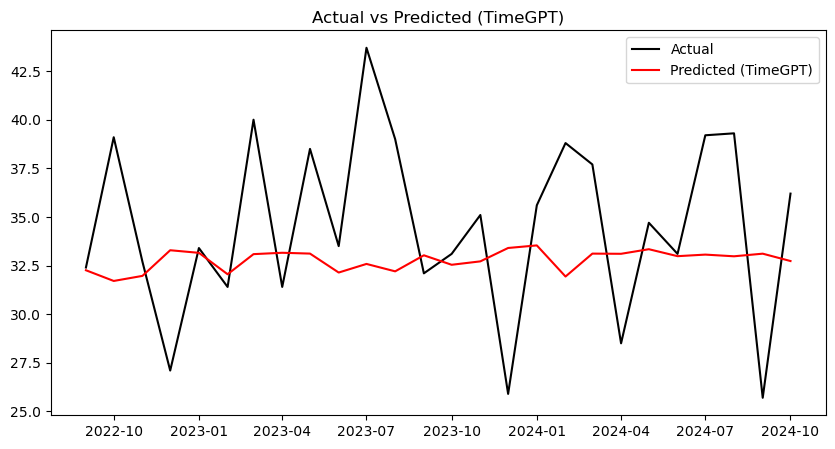

RMSE: 5.00
MAPE: 11.45%


In [7]:
# Metrics Calculation
rmse_timegpt = np.sqrt(mean_squared_error(test_data['value'], forecast_df['TimeGPT']))
mape_timegpt = mean_absolute_percentage_error(test_data['value'], forecast_df['TimeGPT'])

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(test_data['timestamp'], test_data['value'], label="Actual", color="black")
plt.plot(forecast_df.index, forecast_df['TimeGPT'], label="Predicted (TimeGPT)", color="red")
plt.title("Actual vs Predicted (TimeGPT)")
plt.legend()
plt.show()

print(f"RMSE: {rmse_timegpt:.2f}")
print(f"MAPE: {mape_timegpt:.2%}")


### very flat line, seems to show an average rather than actual results so might not be useful.

## TimeGPT with Feature Engineering External Exogenous Variables
- add STB arrivals?

Exogenous variables or external factors are crucial in time series forecasting as they provide additional information that might influence the prediction. These variables could include holiday markers, marketing spending, weather data, or any other external data that correlate with the time series data you are forecasting.

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Using future exogenous features: ['sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12', 'year', 'month']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


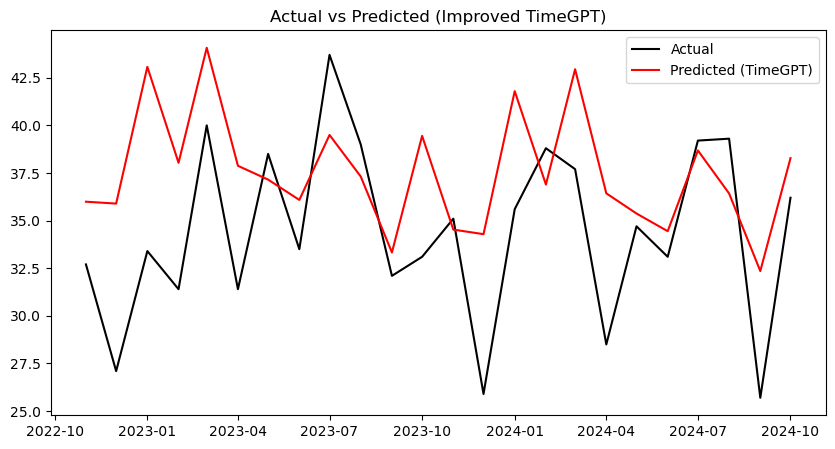

RMSE: 5.07
MAPE: 13.16%


In [21]:
from nixtla import NixtlaClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Initialize NixtlaClient
nixtla_client = NixtlaClient(api_key="nixak-bRnMkOWweCmmc3EJgvV81kqMjxNlsKMjyfurblXaTxmcb4weXihsHP6rGFB6LnlKWjgZ1hJFHVivCfbK")

# Load and preprocess data
df = pd.read_csv('acm_ts.csv')
df['timestamp'] = pd.to_datetime(df['Reporting Period'], format='%Y %b')
df.rename(columns={"Value": "value"}, inplace=True)

# Feature Engineering
df['month'] = df['timestamp'].dt.month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['lag_1'] = df['value'].shift(1)  # Previous month's value
df['lag_12'] = df['value'].shift(12)  # Same month last year
df['monthly_avg'] = df.groupby(df['month'])['value'].transform('mean')  # Historical monthly average

# Drop NaN rows created by lagging
df.dropna(inplace=True)

# Train-test split (80-20)
split_point = int(len(df) * 0.8)
train_data = df[:split_point]
test_data = df[split_point:]

# Prepare Exogenous DataFrame for Future Predictions
future_dates = test_data[['timestamp']].copy()
future_dates['sin_month'] = np.sin(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['cos_month'] = np.cos(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['monthly_avg'] = test_data['monthly_avg'].values
future_dates['lag_1'] = train_data['value'].iloc[-1]  # Last value from train as lag_1
future_dates['lag_12'] = train_data['value'].iloc[-12]  # Value 12 months back as lag_12

# Forecast using TimeGPT
forecast_horizon = len(test_data)
forecast_df = nixtla_client.forecast(
    df=train_data[['timestamp', 'value', 'sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12']],
    h=forecast_horizon,
    time_col="timestamp",
    target_col="value",
    X_df=future_dates,  # Future exogenous variables for predictions
    date_features=True,  # Automatically adds date-related features
    model='timegpt-1-long-horizon'  # Suitable for longer-term forecasts
)

# Parse forecast results
forecast_df['timestamp'] = pd.to_datetime(forecast_df['timestamp'])
forecast_df.set_index('timestamp', inplace=True)

# Metrics Calculation
rmse_timegpt = np.sqrt(mean_squared_error(test_data['value'], forecast_df['TimeGPT']))
mape_timegpt = mean_absolute_percentage_error(test_data['value'], forecast_df['TimeGPT'])

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(test_data['timestamp'], test_data['value'], label="Actual", color="black")
plt.plot(forecast_df.index, forecast_df['TimeGPT'], label="Predicted (TimeGPT)", color="red")
plt.title("Actual vs Predicted (Improved TimeGPT)")
plt.legend()
plt.show()

# Print Metrics
print(f"RMSE: {rmse_timegpt:.2f}")
print(f"MAPE: {mape_timegpt:.2%}")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Using future exogenous features: ['sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12', 'year', 'month']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


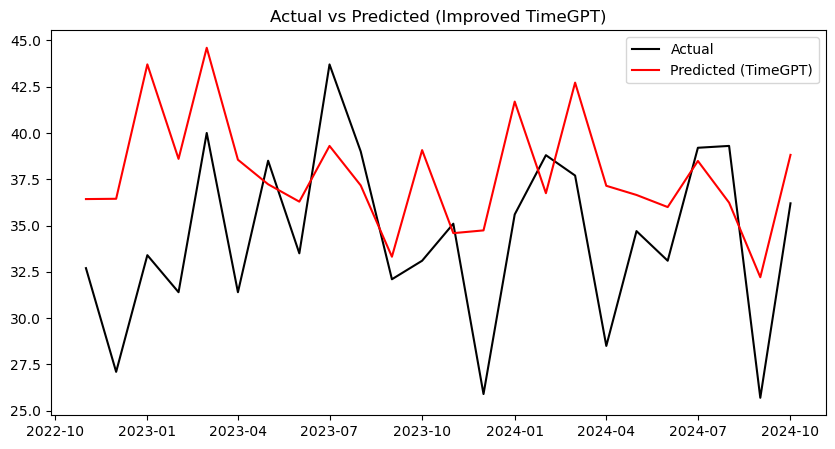

RMSE: 5.37
MAPE: 14.18%


In [24]:
from nixtla import NixtlaClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Initialize NixtlaClient
nixtla_client = NixtlaClient(api_key="nixak-bRnMkOWweCmmc3EJgvV81kqMjxNlsKMjyfurblXaTxmcb4weXihsHP6rGFB6LnlKWjgZ1hJFHVivCfbK")

# Load and preprocess data
df = pd.read_csv('acm_ts.csv')
df['timestamp'] = pd.to_datetime(df['Reporting Period'], format='%Y %b')
df.rename(columns={"Value": "value"}, inplace=True)

# Feature Engineering
df['month'] = df['timestamp'].dt.month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['lag_1'] = df['value'].shift(1)  # Previous month's value
df['lag_12'] = df['value'].shift(12)  # Same month last year
df['monthly_avg'] = df.groupby(df['month'])['value'].transform('mean')  # Historical monthly average

# Drop NaN rows created by lagging
df.dropna(inplace=True)

# Train-test split (80-20)
split_point = int(len(df) * 0.8)
train_data = df[:split_point]
test_data = df[split_point:]

# Prepare Exogenous DataFrame for Future Predictions
future_dates = test_data[['timestamp']].copy()
future_dates['sin_month'] = np.sin(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['cos_month'] = np.cos(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['monthly_avg'] = test_data['monthly_avg'].values
future_dates['lag_1'] = train_data['value'].iloc[-1]  # Last value from train as lag_1
future_dates['lag_12'] = train_data['value'].iloc[-12]  # Value 12 months back as lag_12

# Forecast using TimeGPT
forecast_horizon = len(test_data)
forecast_df = nixtla_client.forecast(
    df=train_data[['timestamp', 'value', 'sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12']],
    h=forecast_horizon,
    time_col="timestamp",
    target_col="value",
    X_df=future_dates,  # Future exogenous variables for predictions
    date_features=True,  # Automatically adds date-related features
    model='timegpt-1'  # Suitable for longer-term forecasts
)

# Parse forecast results
forecast_df['timestamp'] = pd.to_datetime(forecast_df['timestamp'])
forecast_df.set_index('timestamp', inplace=True)

# Metrics Calculation
rmse_timegpt = np.sqrt(mean_squared_error(test_data['value'], forecast_df['TimeGPT']))
mape_timegpt = mean_absolute_percentage_error(test_data['value'], forecast_df['TimeGPT'])

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(test_data['timestamp'], test_data['value'], label="Actual", color="black")
plt.plot(forecast_df.index, forecast_df['TimeGPT'], label="Predicted (TimeGPT)", color="red")
plt.title("Actual vs Predicted (Improved TimeGPT)")
plt.legend()
plt.show()

# Print Metrics
print(f"RMSE: {rmse_timegpt:.2f}")
print(f"MAPE: {mape_timegpt:.2%}")

In [ ]:
#TimeGPT with Fine Tuning with a specific parameter in mind.

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12', 'year', 'month']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


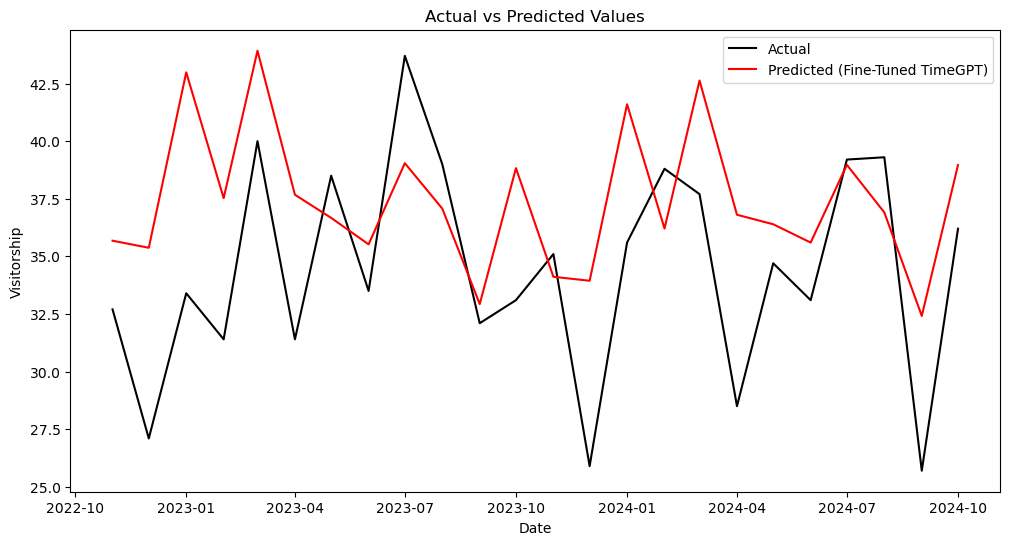

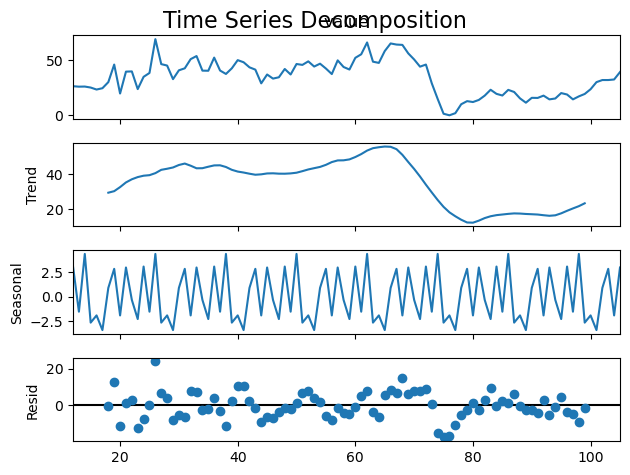

Largest seasonal factor: 4.37
Lowest seasonal factor: -3.44
Ljung-Box Test Results:
    lb_stat  lb_pvalue
47      NaN        NaN


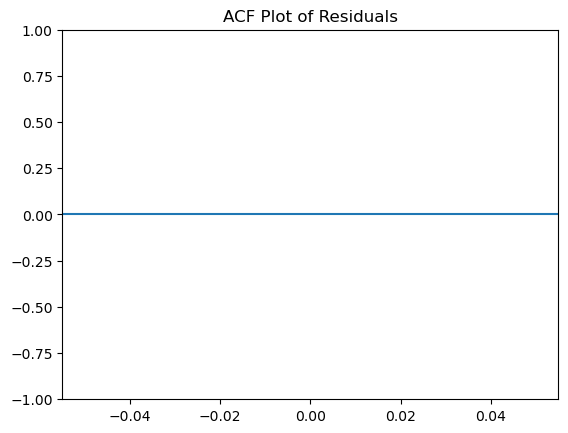

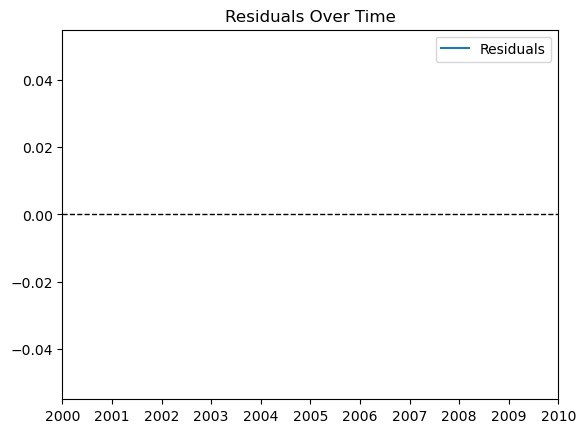

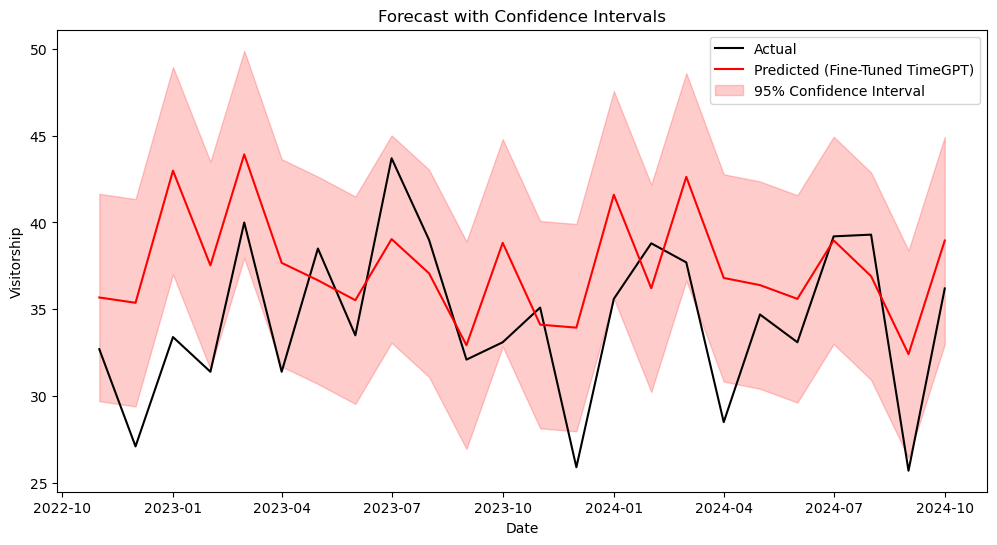

RMSE: 4.99
MAPE: 13.18%


In [30]:


# Initialize NixtlaClient
#nixtla_client = NixtlaClient(api_key="your_api_key_here")

# Load and preprocess data
df = pd.read_csv('acm_ts.csv')
df['timestamp'] = pd.to_datetime(df['Reporting Period'], format='%Y %b')
df.rename(columns={"Value": "value"}, inplace=True)

# Feature Engineering
df['month'] = df['timestamp'].dt.month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['lag_1'] = df['value'].shift(1)  # Previous month's value
df['lag_12'] = df['value'].shift(12)  # Same month last year
df['monthly_avg'] = df.groupby(df['month'])['value'].transform('mean')  # Historical monthly average

# Drop NaN rows created by lagging
df.dropna(inplace=True)

# Train-test split (80-20)
split_point = int(len(df) * 0.8)
train_data = df[:split_point]
test_data = df[split_point:]

# Prepare Exogenous DataFrame for Future Predictions
future_dates = test_data[['timestamp']].copy()
future_dates['sin_month'] = np.sin(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['cos_month'] = np.cos(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['monthly_avg'] = test_data['monthly_avg'].values
future_dates['lag_1'] = train_data['value'].iloc[-1]  # Last value from train as lag_1
future_dates['lag_12'] = train_data['value'].iloc[-12]  # Value 12 months back as lag_12

# Fine-tuned Forecast using TimeGPT
forecast_horizon = len(test_data)
finetune_steps = 10  # Number of fine-tuning steps
finetune_loss = 'mae'  # Mean Absolute Error as the loss function for fine-tuning

forecast_df = nixtla_client.forecast(
    df=train_data[['timestamp', 'value', 'sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12']],
    h=forecast_horizon,
    time_col="timestamp",
    target_col="value",
    X_df=future_dates,  # Future exogenous variables for predictions
    date_features=True,  # Automatically adds date-related features
    model='timegpt-1',  # Suitable for longer-term forecasts
    finetune_steps=finetune_steps,  # Fine-tuning steps
    finetune_loss=finetune_loss  # Fine-tuning loss function
)

# Parse forecast results
forecast_df['timestamp'] = pd.to_datetime(forecast_df['timestamp'])
forecast_df.set_index('timestamp', inplace=True)

# Metrics Calculation
rmse_timegpt = np.sqrt(mean_squared_error(test_data['value'], forecast_df['TimeGPT']))
mape_timegpt = mean_absolute_percentage_error(test_data['value'], forecast_df['TimeGPT'])

# Visualization 1: Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(test_data['timestamp'], test_data['value'], label='Actual', color='black')
plt.plot(forecast_df.index, forecast_df['TimeGPT'], label='Predicted (Fine-Tuned TimeGPT)', color='red')
plt.title("Actual vs Predicted Values")
plt.xlabel("Date")
plt.ylabel("Visitorship")
plt.legend()
plt.show()

# Time Series Decomposition
decomposition = seasonal_decompose(train_data['value'], period=12, model='additive')
decomposition.plot()
plt.suptitle("Time Series Decomposition", fontsize=16)
plt.show()

# Largest seasonal factor insight
seasonal_max = decomposition.seasonal.max()
seasonal_min = decomposition.seasonal.min()
print(f"Largest seasonal factor: {seasonal_max:.2f}")
print(f"Lowest seasonal factor: {seasonal_min:.2f}")

# Autocorrelation Analysis
# Autocorrelation Analysis
def acf_test(residuals):
    # Determine the maximum number of lags allowed
    max_lags = min(50, len(residuals) - 1)
    
    print("Ljung-Box Test Results:")
    lb_test = acorr_ljungbox(residuals, lags=[max_lags], return_df=True)
    print(lb_test)
    
    # ACF Plot
    plot_acf(residuals, lags=max_lags)
    plt.title("ACF Plot of Residuals")
    plt.show()
    
    # Line Plot of Residuals
    plt.plot(residuals, label="Residuals")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title("Residuals Over Time")
    plt.legend()
    plt.show()


# Residuals from the forecast
residuals = test_data['value'] - forecast_df['TimeGPT']
acf_test(residuals)

# Visualization 2: Forecast with Confidence Intervals
forecast_df['lower_ci'] = forecast_df['TimeGPT'] - 1.96 * forecast_df['TimeGPT'].std()
forecast_df['upper_ci'] = forecast_df['TimeGPT'] + 1.96 * forecast_df['TimeGPT'].std()

plt.figure(figsize=(12, 6))
plt.plot(test_data['timestamp'], test_data['value'], label='Actual', color='black')
plt.plot(forecast_df.index, forecast_df['TimeGPT'], label='Predicted (Fine-Tuned TimeGPT)', color='red')
plt.fill_between(forecast_df.index, forecast_df['lower_ci'], forecast_df['upper_ci'], color='red', alpha=0.2, label='95% Confidence Interval')
plt.title("Forecast with Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Visitorship")
plt.legend()
plt.show()

# Print Metrics
print(f"RMSE: {rmse_timegpt:.2f}")
print(f"MAPE: {mape_timegpt:.2%}")


## Final Prediction with Fine tuning

In [9]:

# Load and preprocess data
df = pd.read_csv('acm_ts.csv')
df['timestamp'] = pd.to_datetime(df['Reporting Period'], format='%Y %b')
df.rename(columns={"Value": "value"}, inplace=True)

# Feature Engineering
df['month'] = df['timestamp'].dt.month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['lag_1'] = df['value'].shift(1)  # Previous month's value
df['lag_12'] = df['value'].shift(12)  # Same month last year
df['monthly_avg'] = df.groupby(df['month'])['value'].transform('mean')  # Historical monthly average

# Drop NaN rows created by lagging
df.dropna(inplace=True)

# Train-test split (80-20)
split_point = int(len(df) * 0.8)
train_data = df[:split_point]
test_data = df[split_point:]

# Prepare Exogenous DataFrame for Future Predictions
future_dates = test_data[['timestamp']].copy()
future_dates['sin_month'] = np.sin(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['cos_month'] = np.cos(2 * np.pi * future_dates['timestamp'].dt.month / 12)
future_dates['monthly_avg'] = test_data['monthly_avg'].values
future_dates['lag_1'] = train_data['value'].iloc[-1]  # Last value from train as lag_1
future_dates['lag_12'] = train_data['value'].iloc[-12]  # Value 12 months back as lag_12

# Forecast using Nixtla
forecast_horizon = len(test_data)
finetune_steps = 10  # Number of fine-tuning steps
finetune_loss = 'mae'  # Mean Absolute Error as the loss function for fine-tuning
#finetune_loss = 'rmse'  # tried tuning for rmse but got both worse results fr rmse and mape


forecast_df = nixtla_client.forecast(
    df=train_data[['timestamp', 'value', 'sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12']],
    h=forecast_horizon,
    time_col="timestamp",
    target_col="value",
    X_df=future_dates,  # Future exogenous variables for predictions
    date_features=True,  # Automatically adds date-related features
    model='timegpt-1',  # Suitable for longer-term forecasts
    finetune_steps=finetune_steps,  # Fine-tuning steps
    finetune_loss=finetune_loss  # Fine-tuning loss function
)

# Parse forecast results
forecast_df['timestamp'] = pd.to_datetime(forecast_df['timestamp'])
forecast_df.set_index('timestamp', inplace=True)

# Metrics Calculation
rmse_timegpt = np.sqrt(mean_squared_error(test_data['value'], forecast_df['TimeGPT']))
mape_timegpt = mean_absolute_percentage_error(test_data['value'], forecast_df['TimeGPT'])

# Visualization 1: Actual vs Predicted
actual_vs_predicted_data = pd.DataFrame({
    'timestamp': pd.concat([train_data['timestamp'], test_data['timestamp']]),
    'value': pd.concat([train_data['value'], pd.Series(forecast_df['TimeGPT'].values, index=test_data.index)]),
    'Type': ['Actual'] * len(train_data) + ['Predicted'] * len(test_data)
})
actual_vs_predicted_plot = (
    ggplot(actual_vs_predicted_data, aes(x='timestamp', y='value', color='Type')) +
    geom_line() +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Actual vs Predicted Values', x='Year', y='Visitorship') +
    theme_minimal()
)
actual_vs_predicted_plot.draw()

# Visualization 2: Seasonal Decomposition
result = seasonal_decompose(train_data['value'], period=12, model='additive')
seasonal_data = pd.DataFrame({'timestamp': train_data['timestamp'], 'Seasonal': result.seasonal})
seasonal_plot = (
    ggplot(seasonal_data, aes(x='timestamp', y='Seasonal')) +
    geom_line() +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Seasonal Component', x='Year', y='Seasonal Value') +
    theme_minimal()
)
seasonal_plot.draw()

# Visualization 3: Forecast with Confidence Intervals
forecast_df['lower_ci'] = forecast_df['TimeGPT'] - 1.96 * forecast_df['TimeGPT'].std()
forecast_df['upper_ci'] = forecast_df['TimeGPT'] + 1.96 * forecast_df['TimeGPT'].std()
confidence_plot = (
    ggplot(forecast_df.reset_index(), aes(x='timestamp')) +
    geom_line(aes(y='TimeGPT', color="'Forecast'")) +
    geom_ribbon(aes(ymin='lower_ci', ymax='upper_ci'), alpha=0.2) +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Forecast with Confidence Intervals', x='Year', y='Visitorship') +
    theme_minimal()
)
confidence_plot.draw()

# Visualization 4: Residual Analysis
residuals = test_data['value'] - forecast_df['TimeGPT'].values
residual_data = pd.DataFrame({'timestamp': test_data['timestamp'], 'Residuals': residuals})
residual_plot = (
    ggplot(residual_data, aes(x='timestamp', y='Residuals')) +
    geom_line() +
    geom_hline(yintercept=0, linetype='dashed') +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Residuals Over Time', x='Year', y='Residuals') +
    theme_minimal()
)
residual_plot.draw()

# Print Metrics
print(f"RMSE: {rmse_timegpt:.2f}")
print(f"MAPE: {mape_timegpt:.2%}")


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: MS
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['sin_month', 'cos_month', 'monthly_avg', 'lag_1', 'lag_12', 'year', 'month']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")
C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")
C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


RMSE: 4.99
MAPE: 13.18%


C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


C:\Users\minli\AppData\Local\Temp\ipykernel_23160\3004948550.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


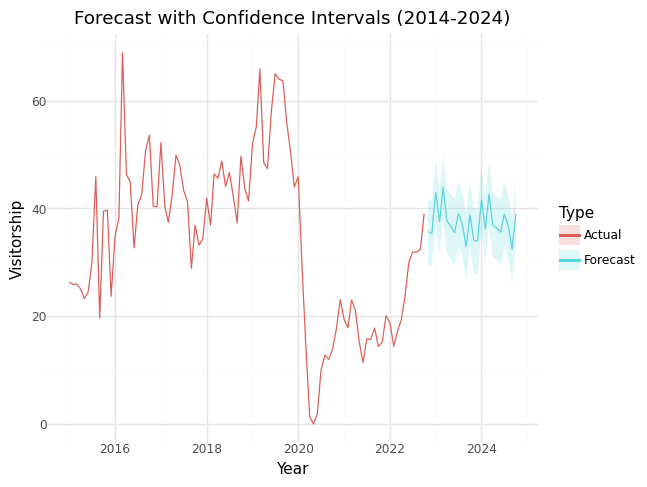

In [12]:
# Extend the data for the confidence plot with only training data for the actual values
forecast_plot_data = pd.concat([
    train_data[['timestamp', 'value']].assign(lower_ci=None, upper_ci=None, Type='Actual'),  # Only training data
    forecast_df.reset_index().rename(columns={'TimeGPT': 'value'}).assign(Type='Forecast')  # Forecast data
], ignore_index=True)

# Confidence Plot with full timeline
forecast_plot = (
    ggplot(forecast_plot_data, aes(x='timestamp')) +
    geom_line(aes(y='value', color='Type')) +
    geom_ribbon(aes(ymin='lower_ci', ymax='upper_ci', fill='Type'), alpha=0.2) +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Forecast with Confidence Intervals (2014-2024)', x='Year', y='Visitorship') +
    theme_minimal()
)
forecast_plot.draw()

## Actual vs predicted plot with confidence interval

C:\Users\minli\AppData\Local\Temp\ipykernel_29244\2170434469.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


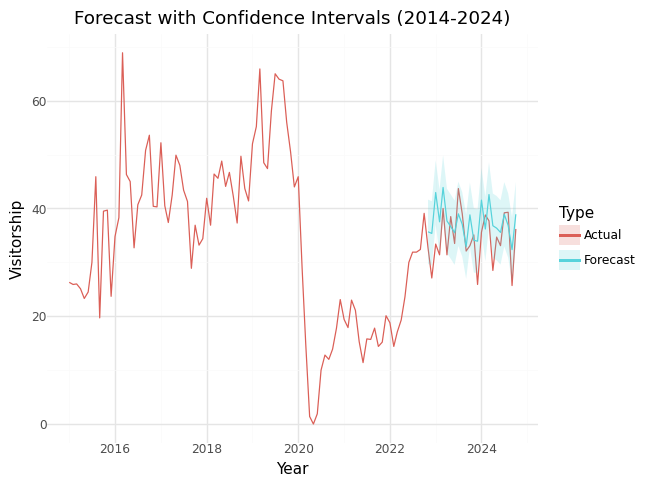

In [107]:
# Extend the data for the confidence plot
confidence_data = pd.concat([
    train_data[['timestamp', 'value']].assign(lower_ci=None, upper_ci=None, Type='Actual'),
    test_data[['timestamp', 'value']].assign(lower_ci=None, upper_ci=None, Type='Actual'),
    forecast_df.reset_index().rename(columns={'TimeGPT': 'value'}).assign(Type='Forecast')
], ignore_index=True)

# Confidence Plot with full timeline
confidence_plot = (
    ggplot(confidence_data, aes(x='timestamp')) +
    geom_line(aes(y='value', color='Type')) +
    geom_ribbon(aes(ymin='lower_ci', ymax='upper_ci', fill='Type'), alpha=0.2) +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Forecast with Confidence Intervals (2014-2024)', x='Year', y='Visitorship') +
    theme_minimal()
)
confidence_plot.draw()


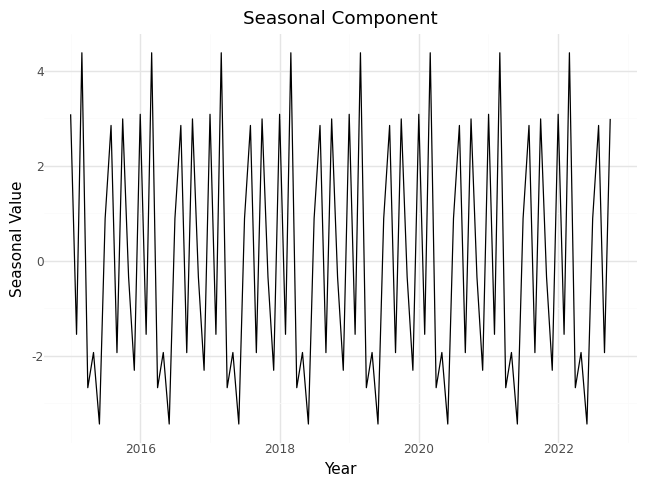

In [13]:
seasonal_plot.draw()

C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


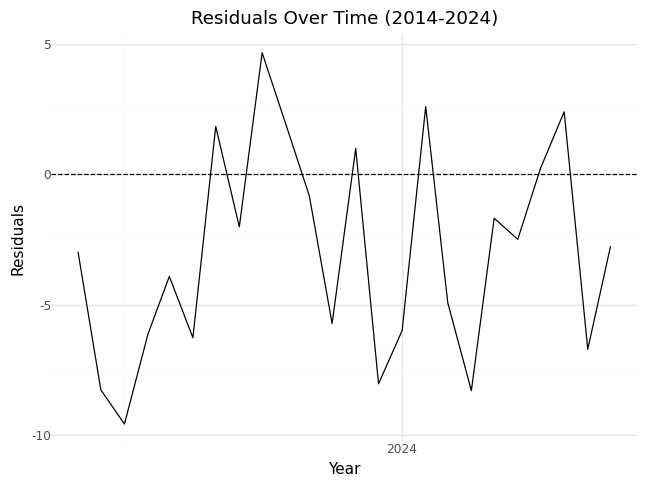

In [15]:
# Residuals for the full dataset
full_residuals_data = pd.DataFrame({
    'timestamp': test_data['timestamp'],
    'Residuals': test_data['value'] - forecast_df['TimeGPT'].values
})

# Residual Plot with full timeline
residual_plot = (
    ggplot(full_residuals_data, aes(x='timestamp', y='Residuals')) +
    geom_line() +
    geom_hline(yintercept=0, linetype='dashed') +
    scale_x_datetime(date_breaks='2 years', date_labels='%Y') +
    labs(title='Residuals Over Time (2014-2024)', x='Year', y='Residuals') +
    theme_minimal()
)
residual_plot.draw()

C:\Users\minli\anaconda3\Lib\site-packages\mizani\breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


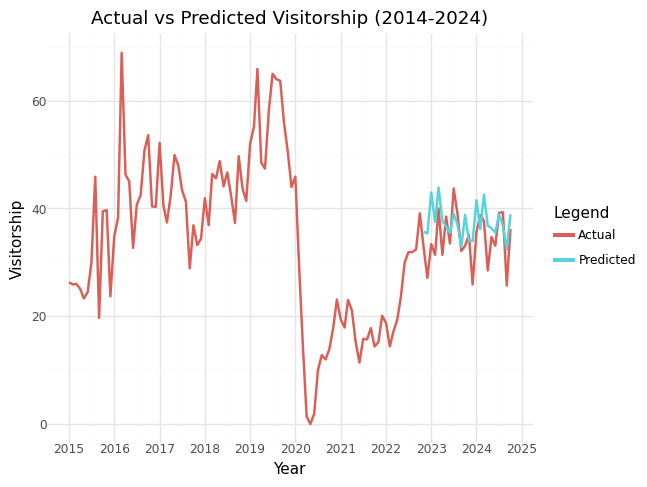

In [115]:
from plotnine import ggplot, aes, geom_line, labs, scale_x_datetime, theme_minimal

# Prepare full_actual_data from df
full_actual_data = df[['timestamp', 'value']].copy()
full_actual_data['Type'] = 'Actual'

forecast_df = forecast_df.reset_index()

# Modify forecasted_data to match the structure of full_actual_data
forecasted_data = pd.DataFrame({
    'timestamp': forecast_df['timestamp'],
    'value': forecast_df['TimeGPT'],
    'Type': 'Predicted'
})

# Ensure forecasted_data is in the correct format (already provided in your example)
forecasted_data = forecasted_data[['timestamp', 'value', 'Type']]

# Combine the actual and predicted data
combined_data = pd.concat([full_actual_data, forecasted_data], ignore_index=True)

# Ensure data is sorted by timestamp
combined_data.sort_values(by='timestamp', inplace=True)

# Create the actual vs predicted plot
actual_vs_predicted_plot = (
    ggplot(combined_data, aes(x='timestamp', y='value', color='Type')) +
    geom_line(size=1.0) +
    scale_x_datetime(date_breaks='1 year', date_labels='%Y') +
    labs(
        title='Actual vs Predicted Visitorship (2014-2024)',
        x='Year',
        y='Visitorship',
        color='Legend'
    ) +
    theme_minimal()
)

# Print the plot
actual_vs_predicted_plot.draw()



## ACF and Box-Ljung Test

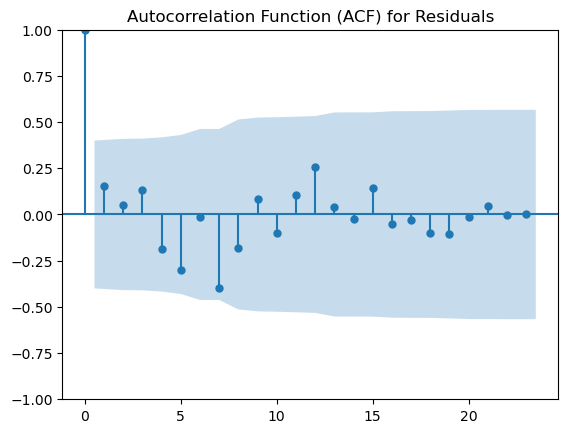

In [22]:
# Adjust lags for ACF to match the length of residuals
max_lags = min(len(residuals) - 1, 40)

# Autocorrelation Function (ACF) Test
acf_plot = plot_acf(residuals, lags=max_lags)
plt.title('Autocorrelation Function (ACF) for Residuals')
plt.show()

In [21]:
# Determine the maximum valid lag based on the residual length
max_lag = len(residuals) - 1

# Generate lags dynamically up to max_lag
valid_lags = [lag for lag in [10, 20, 30] if lag <= max_lag]

# Box-Ljung Test
if valid_lags:  # Only perform the test if there are valid lags
    ljungbox_results = acorr_ljungbox(residuals, lags=valid_lags, return_df=True)
    print("Box-Ljung Test Results:")
    print(ljungbox_results)
else:
    print("Box-Ljung Test skipped: residuals too short for specified lags.")

    # Hypothesis Testing Interpretation
for lag, p_value in zip(ljungbox_results.index, ljungbox_results['lb_pvalue']):
    if p_value < 0.05:
        print(f"Lag {lag}: Reject the null hypothesis (p-value={p_value:.4f}). Residuals are not white noise.")
    else:
        print(f"Lag {lag}: Fail to reject the null hypothesis (p-value={p_value:.4f}). Residuals appear to be white noise.")




Box-Ljung Test Results:
      lb_stat  lb_pvalue
10  13.043334   0.221259
20  21.387817   0.374630
Lag 10: Fail to reject the null hypothesis (p-value=0.2213). Residuals appear to be white noise.
Lag 20: Fail to reject the null hypothesis (p-value=0.3746). Residuals appear to be white noise.
